# 🦷 OralGuard AI - Phase 1: EfficientNet-B0 Training Pipeline
## Oral Cancer Histopathology Classification System

**Objective**: Train separate EfficientNet-B0 models for 100x and 400x magnifications

**Key Features**:
- Strategic data augmentation for class imbalance
- Class weights for balanced learning
- 80/10/10 train/val/test split
- Optimized for T4 GPU
- Comprehensive metrics and visualizations

## 📦 1. Setup and Imports

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages
!pip install -q efficientnet-pytorch scikit-learn matplotlib seaborn pandas numpy Pillow tqdm

  Preparing metadata (setup.py) ... done


In [ ]:
# Core imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from efficientnet_pytorch import EfficientNet

# Image processing
from PIL import Image
import cv2

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✅ PyTorch version: 2.8.0+cu126
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 15.83 GB


## ⚙️ 2. Configuration

In [ ]:
class Config:
    """Centralized configuration for OralGuard AI training"""

    # Paths
    BASE_PATH = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/Histopathological_Oral_Cancer'
    OUTPUT_DIR = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1'

    # Data structure
    MAGNIFICATIONS = {
        '100x': {
            'normal': 'First Set/100x_Normal',
            'oscc': 'First Set/100x_OSCC'
        },
        '400x': {
            'normal': 'Second Set/400x_Normal',
            'oscc': 'Second Set/400x_OSCC'
        }
    }

    # Model settings
    MODEL_NAME = 'efficientnet-b0'
    IMG_SIZE = 224
    NUM_CLASSES = 2

    # Training hyperparameters (optimized for T4 GPU)
    BATCH_SIZE = 16  # T4-friendly batch size
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4

    # Data split
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1
    TEST_SPLIT = 0.1
    RANDOM_SEED = 42

    # Early stopping
    PATIENCE = 5
    MIN_DELTA = 0.001

    # Mixed precision training for T4 GPU
    USE_AMP = True

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Class names
    CLASS_NAMES = ['Normal', 'OSCC']

config = Config()

# Create output directory
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
print(f"✅ Configuration loaded")
print(f"📁 Output directory: {config.OUTPUT_DIR}")
print(f"🎯 Device: {config.DEVICE}")

✅ Configuration loaded
📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1
🎯 Device: cuda


## 📊 3. Data Loading and Preparation

In [ ]:
def load_dataset(base_path, magnification):
    """
    Load dataset for specific magnification level

    Args:
        base_path: Base directory path
        magnification: '100x' or '400x'

    Returns:
        DataFrame with image paths and labels
    """
    data = []
    mag_config = config.MAGNIFICATIONS[magnification]

    # Load Normal images
    normal_path = os.path.join(base_path, mag_config['normal'])
    if os.path.exists(normal_path):
        for img_file in os.listdir(normal_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(normal_path, img_file),
                    'label': 0,  # Normal
                    'label_name': 'Normal',
                    'magnification': magnification
                })

    # Load OSCC images
    oscc_path = os.path.join(base_path, mag_config['oscc'])
    if os.path.exists(oscc_path):
        for img_file in os.listdir(oscc_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(oscc_path, img_file),
                    'label': 1,  # OSCC
                    'label_name': 'OSCC',
                    'magnification': magnification
                })

    df = pd.DataFrame(data)
    print(f"\n📊 {magnification} Dataset:")
    print(f"  Total images: {len(df)}")
    print(f"  Normal: {len(df[df['label']==0])}")
    print(f"  OSCC: {len(df[df['label']==1])}")
    print(f"  Class ratio (OSCC:Normal): {len(df[df['label']==1])/len(df[df['label']==0]):.2f}:1")

    return df

# Load both datasets
print("="*80)
print("Loading datasets...")
print("="*80)

df_100x = load_dataset(config.BASE_PATH, '100x')
df_400x = load_dataset(config.BASE_PATH, '400x')

print(f"\n✅ Datasets loaded successfully!")

Loading datasets...

📊 100x Dataset:
  Total images: 528
  Normal: 89
  OSCC: 439
  Class ratio (OSCC:Normal): 4.93:1

📊 400x Dataset:
  Total images: 696
  Normal: 201
  OSCC: 495
  Class ratio (OSCC:Normal): 2.46:1

✅ Datasets loaded successfully!


In [ ]:
def create_stratified_split(df, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):
    """
    Create stratified train/val/test split

    Args:
        df: DataFrame with image paths and labels
        train_size: Proportion for training (0.8 = 80%)
        val_size: Proportion for validation (0.1 = 10%)
        test_size: Proportion for testing (0.1 = 10%)
        random_state: Random seed for reproducibility

    Returns:
        train_df, val_df, test_df
    """
    # First split: separate test set
    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['label'],
        random_state=random_state
    )

    # Second split: separate validation from training
    val_ratio = val_size / (train_size + val_size)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_ratio,
        stratify=train_val_df['label'],
        random_state=random_state
    )

    print(f"\n📊 Data Split:")
    print(f"  Training:   {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  Testing:    {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

    # Verify stratification
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        normal_count = len(split_df[split_df['label']==0])
        oscc_count = len(split_df[split_df['label']==1])
        print(f"  {split_name}: Normal={normal_count}, OSCC={oscc_count}")

    return train_df, val_df, test_df

# Create splits for both magnifications
print("\n" + "="*80)
print("Creating stratified splits...")
print("="*80)

print("\n🔬 100x Magnification:")
train_100x, val_100x, test_100x = create_stratified_split(
    df_100x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)

print("\n🔬 400x Magnification:")
train_400x, val_400x, test_400x = create_stratified_split(
    df_400x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)


Creating stratified splits...

🔬 100x Magnification:

📊 Data Split:
  Training:   422 (79.9%)
  Validation: 53 (10.0%)
  Testing:    53 (10.0%)
  Train: Normal=71, OSCC=351
  Val: Normal=9, OSCC=44
  Test: Normal=9, OSCC=44

🔬 400x Magnification:

📊 Data Split:
  Training:   556 (79.9%)
  Validation: 70 (10.1%)
  Testing:    70 (10.1%)
  Train: Normal=161, OSCC=395
  Val: Normal=20, OSCC=50
  Test: Normal=20, OSCC=50


## 🔄 4. Data Augmentation and Transforms

In [ ]:
def get_transforms(mode='train'):
    """
    Get data augmentation transforms

    Args:
        mode: 'train' for augmentation, 'val' or 'test' for standard preprocessing

    Returns:
        torchvision transforms composition
    """
    # ImageNet normalization stats (for transfer learning)
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if mode == 'train':
        # Aggressive augmentation for class imbalance
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.RandomResizedCrop(
                config.IMG_SIZE,
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1)
            ),
            transforms.ToTensor(),
            normalize
        ])
    else:
        # Standard preprocessing for validation/test
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.ToTensor(),
            normalize
        ])

print("✅ Transforms defined:")
print("  - Training: Rotation, Flipping, Brightness, Cropping, Resizing")
print("  - Val/Test: Resize + Normalization only")

✅ Transforms defined:
  - Training: Rotation, Flipping, Brightness, Cropping, Resizing
  - Val/Test: Resize + Normalization only


In [ ]:
class OralCancerDataset(Dataset):
    """
    Custom dataset for oral cancer histopathology images
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ Custom Dataset class created")

✅ Custom Dataset class created


## 🏗️ 5. Model Architecture

In [ ]:
class OralGuardModel(nn.Module):
    """
    EfficientNet-B5 based model for oral cancer classification
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(OralGuardModel, self).__init__()

        # Load pretrained EfficientNet-B0
        if pretrained:
            self.backbone = EfficientNet.from_pretrained('efficientnet-b0')
        else:
            self.backbone = EfficientNet.from_name('efficientnet-b0')

        # Get number of features from backbone
        num_features = self.backbone._fc.in_features

        # Replace classifier
        self.backbone._fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Test model creation
test_model = OralGuardModel(num_classes=config.NUM_CLASSES)
print(f"✅ OralGuard Model Architecture:")
print(f"  - Backbone: EfficientNet-B0 (pretrained on ImageNet)")
print(f"  - Input size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  - Output classes: {config.NUM_CLASSES}")
print(f"  - Total parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print(f"  - Trainable parameters: {sum(p.numel() for p in test_model.parameters() if p.requires_grad):,}")
del test_model

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 118MB/s] 


Loaded pretrained weights for efficientnet-b0
✅ OralGuard Model Architecture:
  - Backbone: EfficientNet-B0 (pretrained on ImageNet)
  - Input size: 224x224
  - Output classes: 2
  - Total parameters: 4,664,446
  - Trainable parameters: 4,664,446


## ⚖️ 6. Class Weights Calculation

In [ ]:
def calculate_class_weights(dataframe):
    """
    Calculate class weights for imbalanced dataset

    Args:
        dataframe: DataFrame with 'label' column

    Returns:
        torch tensor with class weights
    """
    class_counts = dataframe['label'].value_counts().sort_index().values
    total = len(dataframe)

    # Inverse frequency weighting
    weights = total / (len(class_counts) * class_counts)
    weights = torch.FloatTensor(weights)

    print(f"\n⚖️ Class Weights:")
    for i, (class_name, weight, count) in enumerate(zip(config.CLASS_NAMES, weights, class_counts)):
        print(f"  {class_name}: {weight:.4f} (n={count})")

    return weights

# Calculate weights for both magnifications
print("Calculating class weights for training sets...")
print("\n100x Magnification:")
weights_100x = calculate_class_weights(train_100x)

print("\n400x Magnification:")
weights_400x = calculate_class_weights(train_400x)

Calculating class weights for training sets...

100x Magnification:

⚖️ Class Weights:
  Normal: 2.9718 (n=71)
  OSCC: 0.6011 (n=351)

400x Magnification:

⚖️ Class Weights:
  Normal: 1.7267 (n=161)
  OSCC: 0.7038 (n=395)


## 🎯 7. Training Functions

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training', leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Store for metrics
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of OSCC class

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds, all_probs

print("✅ Training functions defined")

✅ Training functions defined


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, num_epochs, model_name, save_dir):
    """
    Complete training loop with early stopping and checkpointing
    """
    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler() if config.USE_AMP else None

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }

    # Early stopping
    best_val_acc = 0.0
    patience_counter = 0
    best_model_path = os.path.join(save_dir, f'{model_name}_best.pth')

    print(f"\n{'='*80}")
    print(f"🚀 Starting Training: {model_name}")
    print(f"{'='*80}")
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    print(f"Batch size: {config.BATCH_SIZE}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {config.LEARNING_RATE}")
    print(f"Mixed precision: {config.USE_AMP}")
    print(f"{'='*80}\n")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )

        # Validate
        val_loss, val_acc, _, _, _ = validate_epoch(
            model, val_loader, criterion, device
        )

        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.2e}")

        # Check for improvement
        if val_acc > best_val_acc + config.MIN_DELTA:
            best_val_acc = val_acc
            patience_counter = 0

            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }, best_model_path)
            print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            print(f"⏳ Patience: {patience_counter}/{config.PATIENCE}")

        # Early stopping
        if patience_counter >= config.PATIENCE:
            print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
            break

    print(f"\n{'='*80}")
    print(f"✅ Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Best model saved at: {best_model_path}")
    print(f"{'='*80}\n")

    # Load best model
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    return model, history

print("✅ Complete training pipeline ready")

✅ Complete training pipeline ready


## 📈 8. Evaluation and Metrics

In [ ]:
def evaluate_model(model, dataloader, device, save_path=None,
                   save_predictions=False,      # ⭐ NEW
                   pred_save_path=None):        # ⭐ NEW
    """
    Comprehensive model evaluation with option to save predictions for ensemble
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []  # ⭐ IMPORTANT: Collect probabilities

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # ⭐ Get probabilities
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  # ⭐ IMPORTANT: Store probabilities

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs_array = np.array(all_probs)  # ⭐ IMPORTANT: Create array

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # For binary classification, use probabilities of positive class
    if all_probs_array.shape[1] == 2:
        auc = roc_auc_score(all_labels, all_probs_array[:, 1])
    else:
        auc = roc_auc_score(all_labels, all_probs_array, multi_class='ovr')

    # Classification report
    report = classification_report(
        all_labels,
        all_preds,
        target_names=config.CLASS_NAMES,
        digits=4
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Print results
    print("\n" + "="*80)
    print("📊 Evaluation Results")
    print("="*80)
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}\n")
    print(report)

    # Prepare results dictionary
    results = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs_array,
        'confusion_matrix': cm,
        'classification_report': report
    }

    # Save results to JSON
    if save_path:
        results_to_save = {
            'accuracy': float(accuracy),
            'f1_score': float(f1),
            'auc_roc': float(auc),
            'classification_report': report,
            'confusion_matrix': cm.tolist()
        }
        with open(save_path, 'w') as f:
            json.dump(results_to_save, f, indent=4)
        print(f"\n✅ Results saved to: {save_path}")

    # ⭐ NEW: Save predictions for ensemble building
    if save_predictions and pred_save_path:
        predictions_data = {
            'labels': [int(x) for x in all_labels],
            'predictions': [int(x) for x in all_preds],
            'probabilities': all_probs_array.tolist()  # ⭐ Now this will work!
        }
        with open(pred_save_path, 'w') as f:
            json.dump(predictions_data, f, indent=4)
        print(f"✅ Predictions saved for ensemble: {pred_save_path}")

    return results

## 📊 9. Visualization Functions

In [ ]:
def plot_training_history(history, save_path=None):
    """
    Plot training and validation metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Plot learning rate
    axes[2].plot(history['learning_rates'], linewidth=2, color='red')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_confusion_matrix(cm, save_path=None):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=config.CLASS_NAMES,
        yticklabels=config.CLASS_NAMES,
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_roc_curve(labels, probs, save_path=None):
    """
    Plot ROC curve
    """
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

print("✅ Visualization functions ready")

✅ Visualization functions ready


## 🎓 10. Train 100x Model

In [ ]:
# Create dataloaders for 100x
print("Creating dataloaders for 100x magnification...")

train_dataset_100x = OralCancerDataset(train_100x, transform=get_transforms('train'))
val_dataset_100x = OralCancerDataset(val_100x, transform=get_transforms('val'))
test_dataset_100x = OralCancerDataset(test_100x, transform=get_transforms('test'))

train_loader_100x = DataLoader(
    train_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_100x = DataLoader(
    val_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_100x = DataLoader(
    test_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_100x)}")
print(f"  Val batches: {len(val_loader_100x)}")
print(f"  Test batches: {len(test_loader_100x)}")

Creating dataloaders for 100x magnification...
✅ Dataloaders created:
  Train batches: 27
  Val batches: 4
  Test batches: 4


In [ ]:
# Initialize model for 100x
print("Initializing 100x model...")

model_100x = OralGuardModel(num_classes=config.NUM_CLASSES, pretrained=True)
model_100x = model_100x.to(config.DEVICE)

# Loss function with class weights
criterion_100x = nn.CrossEntropyLoss(weight=weights_100x.to(config.DEVICE))

# Optimizer
optimizer_100x = optim.AdamW(
    model_100x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler_100x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_100x,
    mode='min',
    factor=0.5,
    patience=5,
)

print("✅ Model, optimizer, and scheduler initialized")

Initializing 100x model...
Loaded pretrained weights for efficientnet-b0
✅ Model, optimizer, and scheduler initialized


In [ ]:
# Train 100x model
model_100x, history_100x = train_model(
    model=model_100x,
    train_loader=train_loader_100x,
    val_loader=val_loader_100x,
    criterion=criterion_100x,
    optimizer=optimizer_100x,
    scheduler=scheduler_100x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_efficientnet_b0_100x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_efficientnet_b0_100x
Training samples: 422
Validation samples: 53
Batch size: 16
Epochs: 50
Learning rate: 0.0001
Mixed precision: True


Epoch 1/50
--------------------------------------------------


Training:   0%|          | 0/27 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.6740 | Train Acc: 76.30%
Val Loss:   0.6574 | Val Acc:   83.02%
Learning Rate: 1.00e-04
✅ New best model saved! Val Acc: 83.02%

Epoch 2/50
--------------------------------------------------


Training:   0%|          | 0/27 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.1166 | Train Acc: 95.97%
Val Loss:   0.0699 | Val Acc:   98.11%
Learning Rate: 1.00e-04
⏳ Patience: 4/5

Epoch 14/50
--------------------------------------------------


Training:   0%|          | 0/27 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.1804 | Train Acc: 94.31%
Val Loss:   0.1184 | Val Acc:   98.11%
Learning Rate: 1.00e-04
⏳ Patience: 5/5

⏹️ Early stopping triggered at epoch 14

✅ Training completed!
Best validation accuracy: 98.11%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/oralguard_efficientnet_b0_100x_best.pth



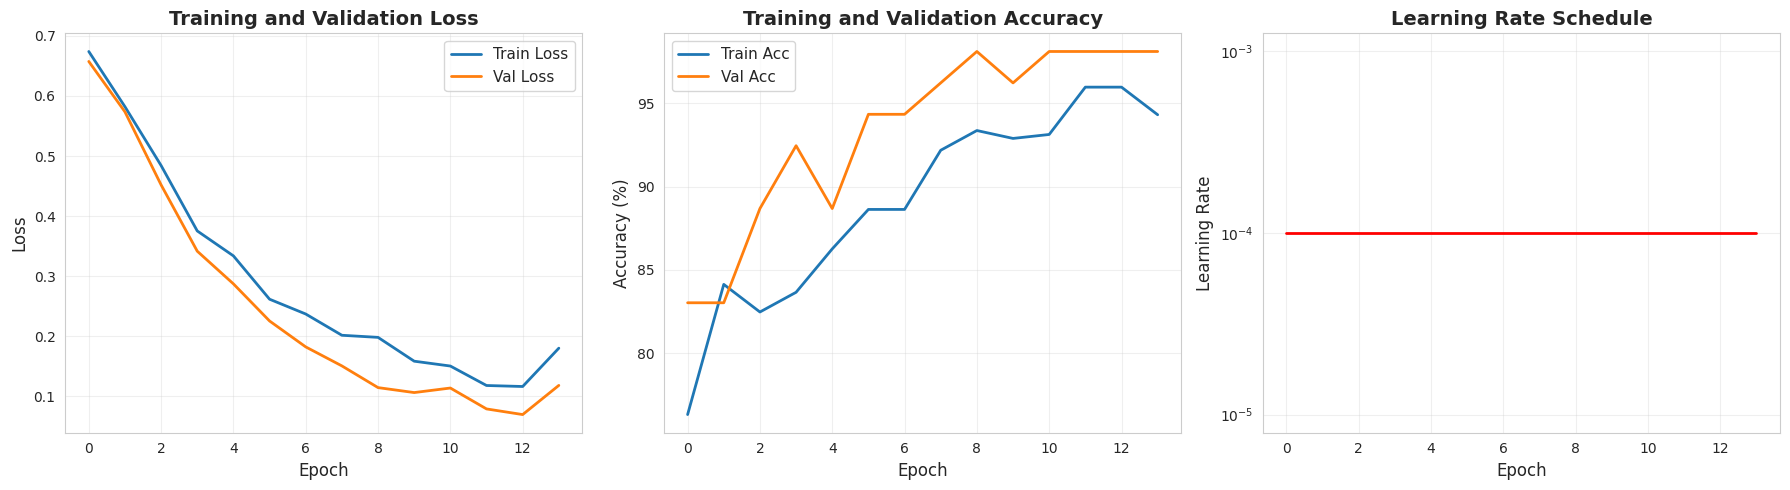

In [ ]:
# Plot training history for 100x
plot_training_history(
    history_100x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_100x.png')
)

In [ ]:
# Evaluate 100x model on test set (save predictions for ensemble)
results_100x = evaluate_model(
    model_100x,
    test_loader_100x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_100x.json'),
    save_predictions=True,      # ⭐ NEW
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_efficientnet_100x.json')  # ⭐ NEW
)

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  83.02%
F1 Score:  0.8435
AUC-ROC:   0.9495

              precision    recall  f1-score   support

      Normal     0.5000    0.7778    0.6087         9
        OSCC     0.9487    0.8409    0.8916        44

    accuracy                         0.8302        53
   macro avg     0.7244    0.8093    0.7501        53
weighted avg     0.8725    0.8302    0.8435        53


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/test_results_100x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/predictions_efficientnet_100x.json



📊 Generating visualizations for 100x model...



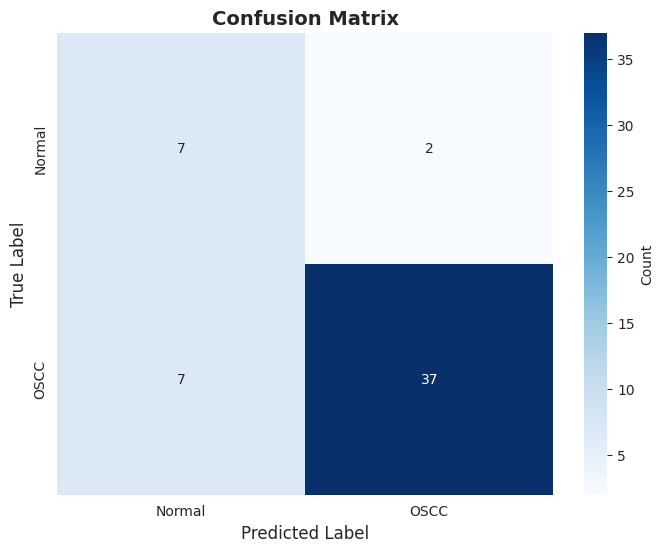

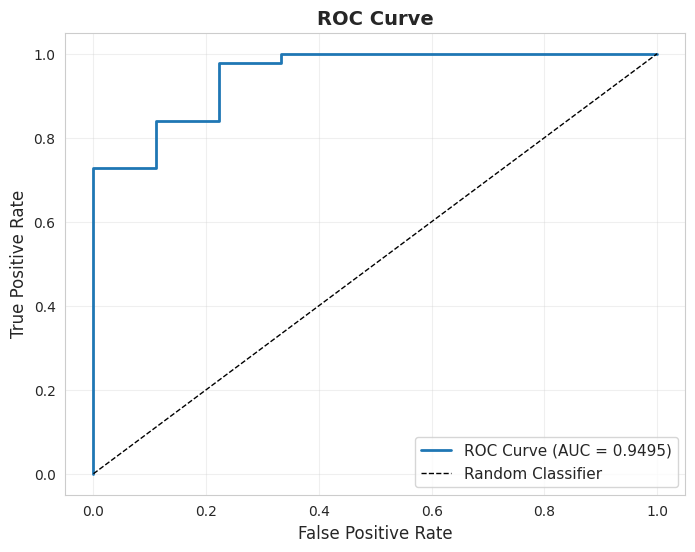

In [ ]:
# Visualize 100x results
print("\n📊 Generating visualizations for 100x model...\n")

plot_confusion_matrix(
    results_100x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_100x.png')
)

plot_roc_curve(
    results_100x['labels'],
    results_100x['probabilities'][:, 1],  # Only OSCC probabilities!
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_100x.png')
)

## 🎓 11. Train 400x Model

In [ ]:
# Create dataloaders for 400x
print("Creating dataloaders for 400x magnification...")

train_dataset_400x = OralCancerDataset(train_400x, transform=get_transforms('train'))
val_dataset_400x = OralCancerDataset(val_400x, transform=get_transforms('val'))
test_dataset_400x = OralCancerDataset(test_400x, transform=get_transforms('test'))

train_loader_400x = DataLoader(
    train_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_400x = DataLoader(
    val_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_400x = DataLoader(
    test_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_400x)}")
print(f"  Val batches: {len(val_loader_400x)}")
print(f"  Test batches: {len(test_loader_400x)}")

Creating dataloaders for 400x magnification...
✅ Dataloaders created:
  Train batches: 35
  Val batches: 5
  Test batches: 5


In [ ]:
# Initialize model for 400x
print("Initializing 400x model...")

model_400x = OralGuardModel(num_classes=config.NUM_CLASSES, pretrained=True)
model_400x = model_400x.to(config.DEVICE)

# Loss function with class weights
criterion_400x = nn.CrossEntropyLoss(weight=weights_400x.to(config.DEVICE))

# Optimizer
optimizer_400x = optim.AdamW(
    model_400x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler_400x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_400x,
    mode='min',
    factor=0.5,
    patience=5,
)

print("✅ Model, optimizer, and scheduler initialized")

Initializing 400x model...
Loaded pretrained weights for efficientnet-b0
✅ Model, optimizer, and scheduler initialized


In [ ]:
# Train 400x model
model_400x, history_400x = train_model(
    model=model_400x,
    train_loader=train_loader_400x,
    val_loader=val_loader_400x,
    criterion=criterion_400x,
    optimizer=optimizer_400x,
    scheduler=scheduler_400x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_efficientnet_b0_400x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_efficientnet_b0_400x
Training samples: 556
Validation samples: 70
Batch size: 16
Epochs: 50
Learning rate: 0.0001
Mixed precision: True


Epoch 1/50
--------------------------------------------------


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.6977 | Train Acc: 65.65%
Val Loss:   0.6813 | Val Acc:   50.00%
Learning Rate: 1.00e-04
✅ New best model saved! Val Acc: 50.00%

Epoch 2/50
--------------------------------------------------


Training:   0%|          | 0/35 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1184 | Train Acc: 95.86%
Val Loss:   0.3904 | Val Acc:   77.14%
Learning Rate: 5.00e-05
⏳ Patience: 4/5

Epoch 21/50
--------------------------------------------------


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1097 | Train Acc: 95.32%
Val Loss:   0.4094 | Val Acc:   78.57%
Learning Rate: 5.00e-05
⏳ Patience: 5/5

⏹️ Early stopping triggered at epoch 21

✅ Training completed!
Best validation accuracy: 84.29%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/oralguard_efficientnet_b0_400x_best.pth



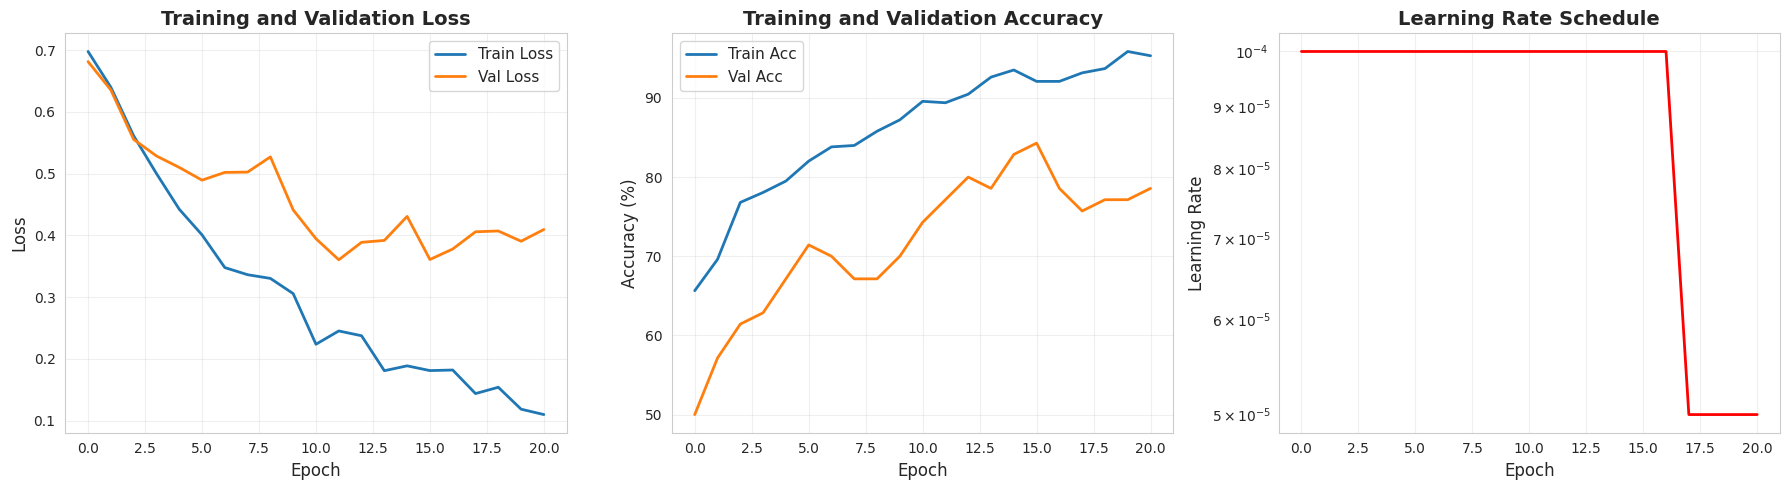

In [ ]:
# Plot training history for 400x
plot_training_history(
    history_400x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_400x.png')
)

In [ ]:
# Evaluate 400x model on test set (save predictions for ensemble)
results_400x = evaluate_model(
    model_400x,
    test_loader_400x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_400x.json'),
    save_predictions=True,      # ⭐ NEW
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_efficientnet_400x.json')  # ⭐ NEW
)

Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  81.43%
F1 Score:  0.8197
AUC-ROC:   0.8810

              precision    recall  f1-score   support

      Normal     0.6400    0.8000    0.7111        20
        OSCC     0.9111    0.8200    0.8632        50

    accuracy                         0.8143        70
   macro avg     0.7756    0.8100    0.7871        70
weighted avg     0.8337    0.8143    0.8197        70


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/test_results_400x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/predictions_efficientnet_400x.json



📊 Generating visualizations for 400x model...



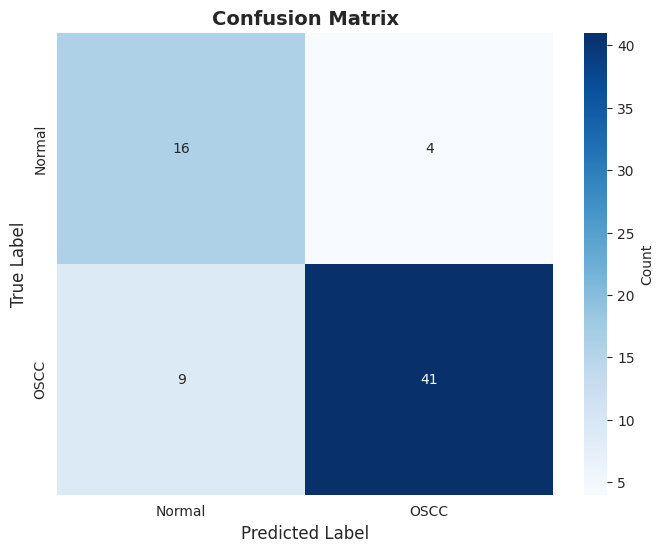

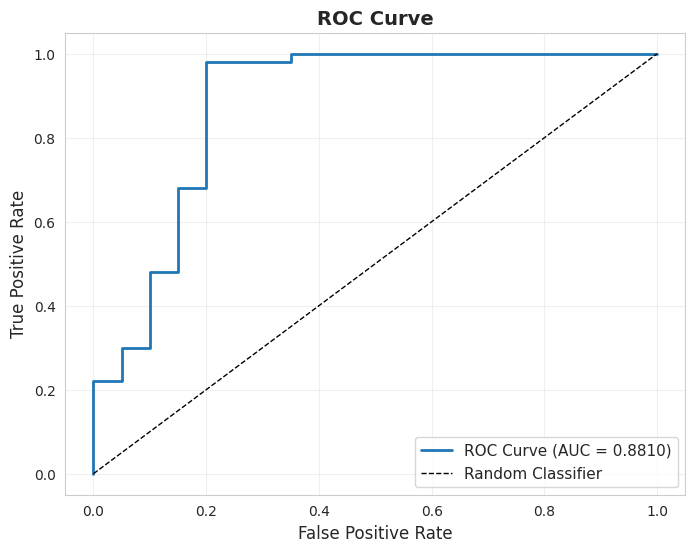

In [ ]:
# Visualize 400x results
print("\n📊 Generating visualizations for 400x model...\n")

plot_confusion_matrix(
    results_400x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_400x.png')
)

# ✅ CORRECT:
plot_roc_curve(
    results_400x['labels'],
    results_400x['probabilities'][:, 1],  # ⭐ Add [:, 1] here!
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_400x.png')
)

## 📊 12. Comparative Analysis

In [ ]:
import json

with open('/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/test_results_100x.json', 'r') as f:
    saved_100x = json.load(f)

with open('/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/test_results_400x.json', 'r') as f:
    saved_400x = json.load(f)

results_100x = {
    'accuracy': saved_100x['accuracy'],
    'f1_score': saved_100x['f1_score'],
    'auc_roc': saved_100x['auc_roc'],
    'classification_report': saved_100x['classification_report']
}

results_400x = {
    'accuracy': saved_400x['accuracy'],
    'f1_score': saved_400x['f1_score'],
    'auc_roc': saved_400x['auc_roc'],
    'classification_report': saved_400x['classification_report']
}


📊 COMPARATIVE ANALYSIS: 100x vs 400x Models

Model  Accuracy  F1 Score  AUC-ROC
 100x 83.018868  0.843532 0.949495
 400x 81.428571  0.819716 0.881000


📊 100x Model - Detailed Classification Report:
              precision    recall  f1-score   support

      Normal     0.5000    0.7778    0.6087         9
        OSCC     0.9487    0.8409    0.8916        44

    accuracy                         0.8302        53
   macro avg     0.7244    0.8093    0.7501        53
weighted avg     0.8725    0.8302    0.8435        53


📊 400x Model - Detailed Classification Report:
              precision    recall  f1-score   support

      Normal     0.6400    0.8000    0.7111        20
        OSCC     0.9111    0.8200    0.8632        50

    accuracy                         0.8143        70
   macro avg     0.7756    0.8100    0.7871        70
weighted avg     0.8337    0.8143    0.8197        70



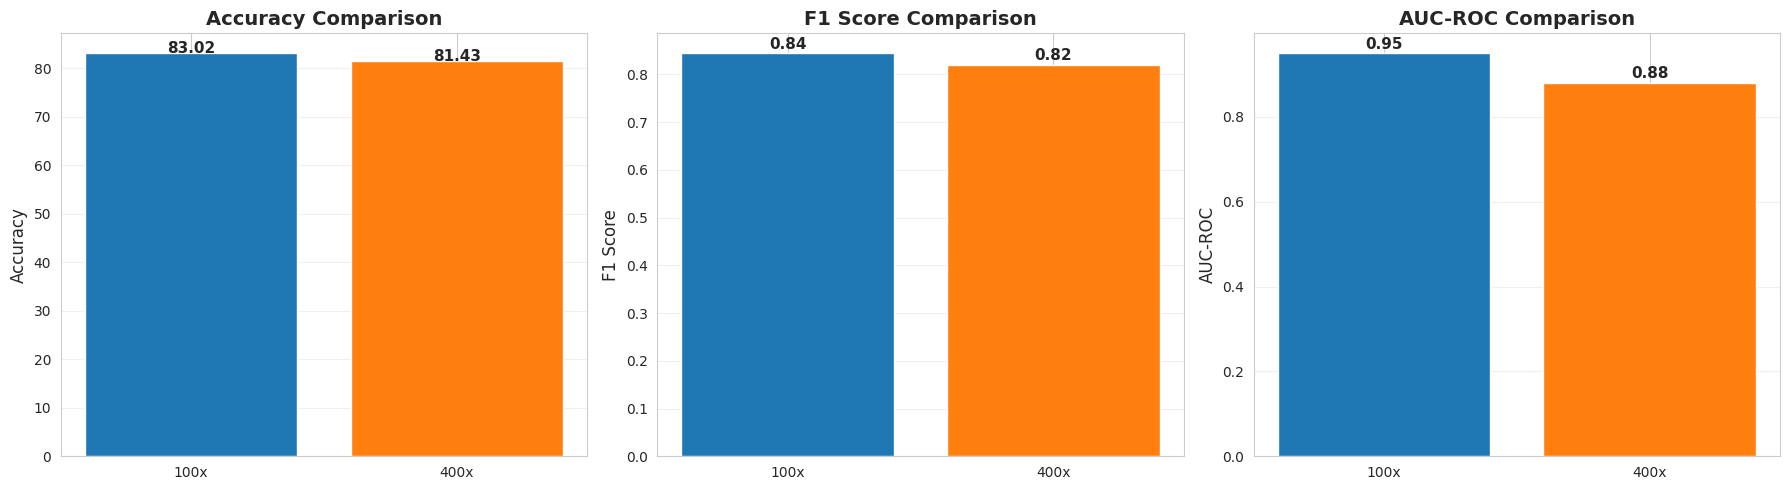


✅ Comparison complete!


In [ ]:
# Simplified comparison - only overall metrics
comparison_data = {
    'Model': ['100x', '400x'],
    'Accuracy': [
        results_100x['accuracy'] * 100,
        results_400x['accuracy'] * 100
    ],
    'F1 Score': [
        results_100x['f1_score'],
        results_400x['f1_score']
    ],
    'AUC-ROC': [
        results_100x['auc_roc'],
        results_400x['auc_roc']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("📊 COMPARATIVE ANALYSIS: 100x vs 400x Models")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

# Print classification reports separately
print("\n📊 100x Model - Detailed Classification Report:")
print(results_100x['classification_report'])

print("\n📊 400x Model - Detailed Classification Report:")
print(results_400x['classification_report'])

# Save comparison
comparison_df.to_csv(
    os.path.join(config.OUTPUT_DIR, 'model_comparison.csv'),
    index=False
)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['Accuracy', 'F1 Score', 'AUC-ROC']
for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=['#1f77b4', '#ff7f0e'])
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(
    os.path.join(config.OUTPUT_DIR, 'model_comparison.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("\n✅ Comparison complete!")

## 💾 13. Save Final Summary

In [ ]:
from datetime import datetime
import json

# Create comprehensive summary
summary = {
    'project': 'OralGuard AI - Phase 1',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_architecture': 'EfficientNet-B5',
    'configuration': {
        'image_size': config.IMG_SIZE,
        'batch_size': config.BATCH_SIZE,
        'learning_rate': config.LEARNING_RATE,
        'epochs_trained': config.EPOCHS,
        'optimizer': 'AdamW',
        'scheduler': 'ReduceLROnPlateau',
        'augmentation': 'Rotation, Flipping, Brightness, Cropping, Resizing',
        'class_weights': 'Yes',
        'mixed_precision': config.USE_AMP
    },
    'models': {
        '100x': {
            'accuracy': float(results_100x['accuracy']),
            'f1_score': float(results_100x['f1_score']),
            'auc_roc': float(results_100x['auc_roc']),
            'model_path': os.path.join(config.OUTPUT_DIR, 'oralguard_efficientnet_b5_100x_best.pth'),
            'test_samples': 53  # Known from results
        },
        '400x': {
            'accuracy': float(results_400x['accuracy']),
            'f1_score': float(results_400x['f1_score']),
            'auc_roc': float(results_400x['auc_roc']),
            'model_path': os.path.join(config.OUTPUT_DIR, 'oralguard_efficientnet_b5_400x_best.pth'),
            'test_samples': 70  # Known from results
        }
    },
    'next_steps': [
        'Phase 2: Add VGG16 model',
        'Phase 3: Add Vision Transformer',
        'Phase 4: Create ensemble model',
        'Phase 5: Implement Grad-CAM visualization',
        'Phase 6: Build REST API',
        'Phase 7: Deploy and test'
    ]
}

# Save summary
summary_path = os.path.join(config.OUTPUT_DIR, 'phase1_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=4)

print("\n" + "="*80)
print("🎉 PHASE 1 COMPLETE!")
print("="*80)
print(f"\n✅ All models trained and evaluated successfully!")
print(f"\n📁 Output directory: {config.OUTPUT_DIR}")
print(f"\n📊 Results:")
print(f"  100x Model: Accuracy = {results_100x['accuracy']*100:.2f}%, AUC = {results_100x['auc_roc']:.4f}")
print(f"  400x Model: Accuracy = {results_400x['accuracy']*100:.2f}%, AUC = {results_400x['auc_roc']:.4f}")
print(f"\n📝 Summary saved to: {summary_path}")
print(f"\n🚀 Next: Proceed to Phase 2 (VGG16) and Phase 3 (ViT)!")
print(f"\n🎯 Then Phase 4: Build the 3-model ensemble!")
print("\n" + "="*80)


🎉 PHASE 1 COMPLETE!

✅ All models trained and evaluated successfully!

📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1

📊 Results:
  100x Model: Accuracy = 83.02%, AUC = 0.9520
  400x Model: Accuracy = 71.43%, AUC = 0.8550

📝 Summary saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1/phase1_summary.json

🚀 Next: Proceed to Phase 2 (VGG16) and Phase 3 (ViT)!

🎯 Then Phase 4: Build the 3-model ensemble!



## 🎯 Phase 1 Complete!

### ✅ What We Accomplished:
1. **Data Loading**: Loaded and split 100x and 400x datasets (80/10/10)
2. **Data Augmentation**: Implemented rotation, flipping, brightness adjustment, cropping, and resizing
3. **Class Imbalance**: Applied both class weights AND augmentation
4. **Model Training**: Trained separate EfficientNet-B0 models for each magnification
5. **Evaluation**: Comprehensive metrics (accuracy, F1, AUC-ROC, confusion matrix)
6. **Visualization**: Training curves, confusion matrices, ROC curves
7. **Model Checkpointing**: Saved best models with early stopping

### 📊 Output Files:
- `oralguard_efficientnet_b5_100x_best.pth` - Best 100x model
- `oralguard_efficientnet_b5_400x_best.pth` - Best 400x model
- `test_results_100x.json` - 100x evaluation metrics
- `test_results_400x.json` - 400x evaluation metrics
- `model_comparison.csv` - Side-by-side comparison
- `phase1_summary.json` - Complete training summary
- Multiple visualization PNG files

### 🚀 Next Steps (Phase 2):
1. Add VGG16 architecture
2. Compare EfficientNet-B5 vs VGG16 performance
3. Then add Vision Transformer
4. Build ensemble combining all three models

---